# Pytest CLI arguments

* **Run all tests in headless mode**: `pytest`
* **Run single test file in headless mode**: `pytest test.py`
*  **Run tests matching regular expression**: `pytest -k cart*`
* **Run in headed mode (default Chromium browser)**: `pytest --headed --slowmo=1000 test.py`
* **Run in a different browser other than the default Chrome**: `pytest --headed --slowmo=1000 --browser=firefox test.py`
*  **Run in a specific device**: `pytest --device="Pixel 5"`
*  **Tracing on every test**: `pytest --tracing on`
*  **Tracing off**: `pytest --tracing off`
*  **Tracing on every test failure**: `pytest --tracing retain-on-failure`
*  **Generate test execution video recording**: `pytest --video on`
*  **Take a screenshot on test completion**:  `pytest --screenshot on`
*  **Take a screenshot on test failure**:  `pytest --screenshot only-on-failure`

# Python Debugger

* We'll learn to use the Python debugger inside the playwright tests.
* To do that, we can simply use the `breakpoint()` function at the place where we want to break out.
* The `breakpoint()` function will open an interactive Python shell where we can interact with the elements like the page & elements, and execute Python code line by line.

**Example**:

```python
from playwright.sync_api import Page, expect, Route

def test_page_has_docs_link(page: Page):
    page.goto("https://playwright.dev/python")
    link = page.get_by_role("link", name="docs")
    expect(link).to_be_visible()


def test_get_started_link(page: Page):
    page.goto("https://playwright.dev/python")
    link = page.get_by_role("link", name="GET STARTED")

    breakpoint()

    link.click()
    expect(page).to_have_url("https://playwright.dev/python/docs/intro")
```
**Run test**: `pytest`

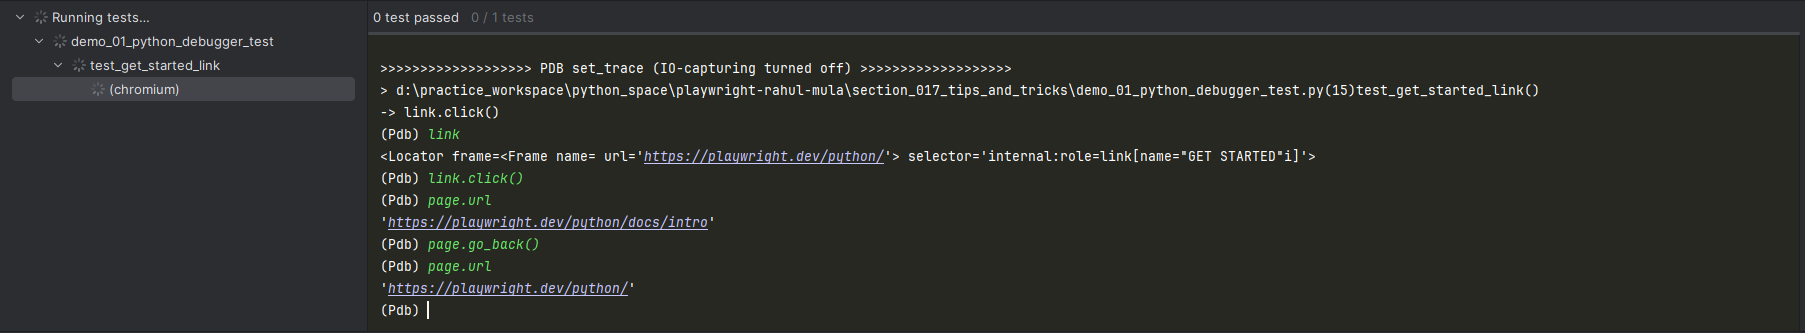

**Enter `continue` to resume the session**

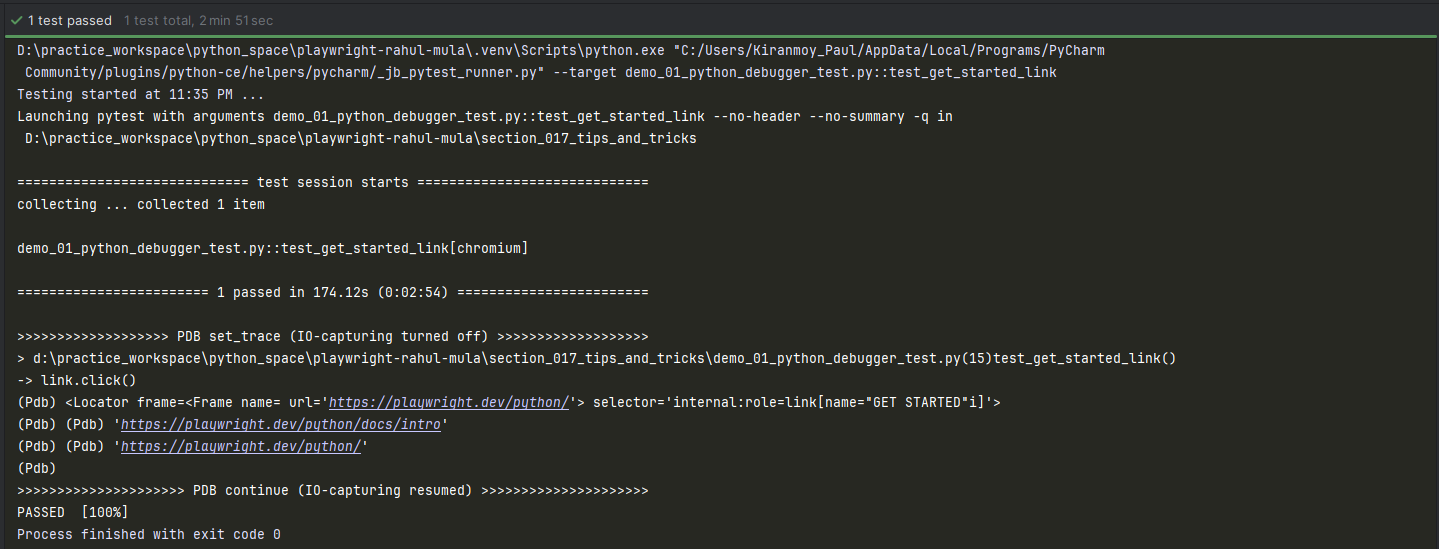

# Device Emulation

* By default, the browser acts as a desktop browser, but it can also emulate various other device types.
* We can do that using browser `context` and its different options.

**Example**:

```python

from playwright.sync_api import sync_playwright, ViewportSize

def test_device_emulation_1():

    with sync_playwright() as playwright:
        browser = playwright.chromium.launch(headless=False,slow_mo=1000)

        # get device configuration arguments
        pixel_5_args = playwright.devices["Pixel 5"]

        # pass device configuration arguments to browser context to emulate the device
        context = browser.new_context(**pixel_5_args)

        page = context.new_page()
        page.goto("https://playwright.dev/python")
        link = page.get_by_role('link', name="GET STARTED")
        link.click()

        context.close()

def test_device_emulation_2():
    with sync_playwright() as playwright:
        browser = playwright.chromium.launch(headless=False, slow_mo=1000)

        # pass custom configuration arguments to browser context to emulate the device
        context = browser.new_context(
            is_mobile=True,
            has_touch=True,
            viewport={"width": 1920, "height": 1080},
            color_scheme="dark"
        )

        page = context.new_page()
        page.goto("https://playwright.dev/python")
        link = page.get_by_role('link', name="GET STARTED")
        link.click()

        context.close()

```

# Evaluate JavaScript

We'll learn how to execute custom JavaScript code in our Python script using the `evaluate()` method.

**Example**:

```python
from playwright.sync_api import sync_playwright, ViewportSize

def test_evaluate_js():

    with sync_playwright() as playwright:
        browser = playwright.chromium.launch(headless=False,slow_mo=1000)
        page = browser.new_page()
        page.goto("https://playwright.dev/python")

        page.evaluate("window.scrollBy(0, document.body.scrollHeight)")
        page.screenshot(path="end-of-page.jpg")

        browser.close()
```

# Generate Reports

* We'll learn how to generate HTML reports for our tests using the **pytest-html** plugin.
* Install: `pip install pytest-html`
* To generate an HTML report, run: `pytest . --html=reports/report.html`

If we want to generate the reports everytime we run the tests, then we've to use the pyest configuration file.

**pytest.ini**

```
[pytest]
addopts = --html=reports/report.html
```